# 05_1. Постобработка шума: reduce_outliers

**Вход:** обученная модель Config1 из `05_hyperparams.ipynb`  
**Цель:** применить цепочку стратегий `reduce_outliers` и измерить эффект  
**Методология:** двухэтапная схема Grootendorst - сначала оптимизация гиперпараметров, затем постобработка шума как отдельный шаг  

Стратегии (цепочка, как рекомендует автор BERTopic):
1. `c-tf-idf` - быстрая, не требует embeddings
2. `embeddings` - cosine similarity между doc embedding и topic centroid

После каждого шага пересчитываем метрики и сравниваем с исходным Config1.

## 0. Импорты и пути

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
import hdbscan.validity as dbcv_module

warnings.filterwarnings('ignore')

DATA_DIR = Path("data")
RESULTS_DIR = Path("results/noise_filtering")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = Path("results/hyperparams/bertopic_top1")
PREPROCESSED_PATH = DATA_DIR / "posts_preprocessed.parquet"
EMBEDDINGS_PATH = DATA_DIR / "embeddings_USER-bge-m3.npy"
EMBEDDINGS_FALLBACK = DATA_DIR / "embeddings_USER-bge-m3_300k.npy"
if not EMBEDDINGS_PATH.exists() and EMBEDDINGS_FALLBACK.exists():
    EMBEDDINGS_PATH = EMBEDDINGS_FALLBACK

RANDOM_STATE = 42

def patch_pynndescent() -> bool:
    try:
        from pynndescent import NNDescent
    except Exception:
        return False
    if getattr(NNDescent, "__patched_setstate__", False):
        return True
    original_setstate = NNDescent.__setstate__
    def _patched_setstate(self, d):
        defaults = {
            "quantization": None,
            "_min_distance": 0.0,
            "parallel_batch_queries": False,
        }
        for key, val in defaults.items():
            if key not in d:
                d[key] = val
        original_setstate(self, d)
    NNDescent.__setstate__ = _patched_setstate
    NNDescent.__patched_setstate__ = True
    return True

patch_pynndescent()

print('Импорты готовы')

Импорты готовы


## 1. Загрузка модели и данных из nb05

In [2]:
if not PREPROCESSED_PATH.exists():
    raise FileNotFoundError(f"Не найден файл: {PREPROCESSED_PATH}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Не найдена модель: {MODEL_PATH}")
if not EMBEDDINGS_PATH.exists() and not EMBEDDINGS_FALLBACK.exists():
    raise FileNotFoundError(f"Не найдены эмбеддинги: {EMBEDDINGS_PATH} или {EMBEDDINGS_FALLBACK}")

df = pd.read_parquet(PREPROCESSED_PATH)

embeddings = None
embeddings_path = None
candidates = []
if EMBEDDINGS_PATH.exists():
    candidates.append(EMBEDDINGS_PATH)
if EMBEDDINGS_FALLBACK.exists() and EMBEDDINGS_FALLBACK not in candidates:
    candidates.append(EMBEDDINGS_FALLBACK)
for p in candidates:
    arr = np.load(p)
    if len(arr) == len(df):
        embeddings = arr
        embeddings_path = p
        break
    if embeddings is None:
        embeddings = arr
        embeddings_path = p

if len(df) != len(embeddings):
    raise ValueError(
        f"Размеры не совпадают: df={len(df)}, embeddings={len(embeddings)} (файл: {embeddings_path})"
    )

N_DOCS = 100_000
sample_idx = None
if N_DOCS is not None and len(df) > N_DOCS:
    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(len(df), size=N_DOCS, replace=False)
    sample_idx.sort()
    df = df.iloc[sample_idx].reset_index(drop=True)
    embeddings = embeddings[sample_idx]

docs_lemm = df['text_lemm'].tolist()
docs_clean = df['text_clean'].tolist()

# Загружаем модель Config1
patch_pynndescent()
try:
    topic_model = BERTopic.load(str(MODEL_PATH))
except AttributeError:
    patch_pynndescent()
    topic_model = BERTopic.load(str(MODEL_PATH))

topics_orig, _ = topic_model.transform(docs_lemm, embeddings=embeddings)

print(f'Документов:    {len(df):,}')
print(f'Эмбеддинги:    {embeddings.shape}')
print(f'Тем в модели:  {len(topic_model.get_topics()) - 1}')
print(f'Noise (исходный): {(np.array(topics_orig) == -1).mean():.3f}')

Документов:    100,000
Эмбеддинги:    (100000, 1024)
Тем в модели:  231
Noise (исходный): 0.532


## 2. Базовые метрики Config1 (до постобработки)

Фиксируем точку отсчёта - всё то, что уже есть в nb05.

In [3]:
def compute_metrics(model, topics, docs, label=''):
    """DBCV, C_V coherence, Topic Diversity, Noise Ratio, Classified Ratio."""
    topics_arr = np.array(topics)
    noise_ratio = float((topics_arr == -1).mean())
    classified_ratio = 1.0 - noise_ratio
    n_topics = len([t for t in model.get_topics() if t != -1])

    # DBCV с субсэмплингом
    reduced = model.umap_model.embedding_
    mask = topics_arr != -1
    rng = np.random.default_rng(RANDOM_STATE)
    keep_idx = []
    for cid in np.unique(topics_arr[mask]):
        idx = np.where(topics_arr == cid)[0]
        if len(idx) > 500:
            idx = rng.choice(idx, size=500, replace=False)
        keep_idx.extend(idx.tolist())
    keep_idx = np.array(keep_idx)
    try:
        dbcv = float(dbcv_module.validity_index(
            reduced[keep_idx].astype(np.float64),
            topics_arr[keep_idx]
        ))
    except Exception as e:
        print(f'  DBCV ошибка: {e}')
        dbcv = float('nan')

    # C_V coherence (по лемматизированным текстам)
    topic_words_list = [
        [w for w, _ in model.get_topic(t)]
        for t in model.get_topics() if t != -1
    ]
    tokenized = [d.split() for d in docs]
    dictionary = Dictionary(tokenized)
    valid_tokens = set(dictionary.token2id.keys())
    filtered = [[w for w in wl if w in valid_tokens] for wl in topic_words_list]
    filtered = [wl for wl in filtered if len(wl) >= 2]
    try:
        cm = CoherenceModel(
            topics=filtered, texts=tokenized,
            dictionary=dictionary, coherence='c_v'
        )
        cv = float(cm.get_coherence())
    except Exception as e:
        print(f'  C_V ошибка: {e}')
        cv = float('nan')

    # Topic Diversity
    all_words = [w for wl in topic_words_list for w in wl]
    diversity = len(set(all_words)) / len(all_words) if all_words else 0.0

    result = {
        'label': label,
        'n_topics': n_topics,
        'noise_ratio': round(noise_ratio, 4),
        'classified_ratio': round(classified_ratio, 4),
        'dbcv': round(dbcv, 4),
        'cv_coherence': round(cv, 4),
        'topic_diversity': round(diversity, 4),
    }
    print(f'\n[{label}]')
    for k, v in result.items():
        if k != 'label':
            print(f'  {k:20s}: {v}')
    return result


metrics_before = compute_metrics(topic_model, topics_orig, docs_lemm, label='Config1')


[Config1]
  n_topics            : 231
  noise_ratio         : 0.5324
  classified_ratio    : 0.4676
  dbcv                : -0.9672
  cv_coherence        : 0.7821
  topic_diversity     : 0.7671


## 3. Шаг 1: reduce_outliers стратегия c-tf-idf

Быстрая стратегия - сравнивает c-TF-IDF вектор документа с c-TF-IDF представлениями тем.  
Не требует embeddings, работает за секунды.

`threshold=0.1` - документ переназначается только если сходство с темой > 0.1.  
Значение подбирается ниже через ablation.

In [4]:
# Ablation по порогу для стратегии c-tf-idf
thresholds_to_test = [i/100 for i in range(0, 100, 5)]  # 0.0, 0.05, ..., 0.95
ablation_results = []

for thr in thresholds_to_test:
    new_topics_thr = topic_model.reduce_outliers(
        docs_clean, topics_orig,
        strategy='c-tf-idf',
        threshold=thr
    )
    noise = (np.array(new_topics_thr) == -1).mean()
    classified = 1.0 - noise
    ablation_results.append({
        'threshold': thr,
        'noise_ratio': round(noise, 4),
        'classified_ratio': round(classified, 4),
        'reassigned': int((np.array(topics_orig) == -1).sum()) - int((np.array(new_topics_thr) == -1).sum())
    })
    print(f'  threshold={thr:.2f} -> noise={noise:.3f}, classified={classified:.3f}')

ablation_df = pd.DataFrame(ablation_results)
print('\nAblation c-tf-idf:')
print(ablation_df.to_string(index=False))

  threshold=0.00 -> noise=0.008, classified=0.992
  threshold=0.05 -> noise=0.108, classified=0.892
  threshold=0.10 -> noise=0.300, classified=0.700
  threshold=0.15 -> noise=0.405, classified=0.595
  threshold=0.20 -> noise=0.458, classified=0.542
  threshold=0.25 -> noise=0.488, classified=0.512
  threshold=0.30 -> noise=0.506, classified=0.494
  threshold=0.35 -> noise=0.517, classified=0.483
  threshold=0.40 -> noise=0.523, classified=0.477
  threshold=0.45 -> noise=0.526, classified=0.474
  threshold=0.50 -> noise=0.529, classified=0.471
  threshold=0.55 -> noise=0.530, classified=0.470
  threshold=0.60 -> noise=0.531, classified=0.469
  threshold=0.65 -> noise=0.532, classified=0.468
  threshold=0.70 -> noise=0.532, classified=0.468
  threshold=0.75 -> noise=0.532, classified=0.468
  threshold=0.80 -> noise=0.532, classified=0.468
  threshold=0.85 -> noise=0.532, classified=0.468
  threshold=0.90 -> noise=0.532, classified=0.468
  threshold=0.95 -> noise=0.532, classified=0.468


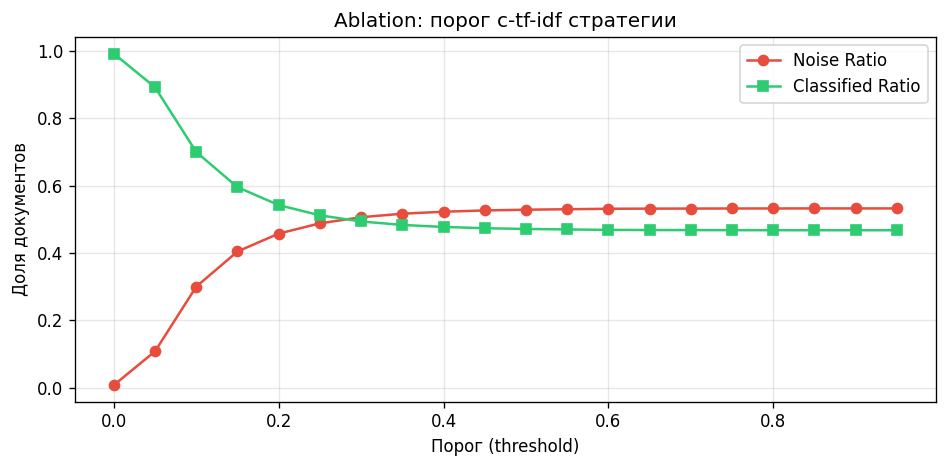

In [5]:
# Визуализация ablation
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ablation_df['threshold'], ablation_df['noise_ratio'], 'o-', label='Noise Ratio', color='#e74c3c')
ax.plot(ablation_df['threshold'], ablation_df['classified_ratio'], 's-', label='Classified Ratio', color='#2ecc71')
ax.set_xlabel('Порог (threshold)')
ax.set_ylabel('Доля документов')
ax.set_title('Ablation: порог c-tf-idf стратегии')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ablation_ctfidf_threshold.png')
plt.show()

In [6]:
THRESHOLD_CTFIDF = 0.4

topics_after_ctfidf = topic_model.reduce_outliers(
    docs_clean, topics_orig,
    strategy='c-tf-idf',
    threshold=THRESHOLD_CTFIDF
)

reassigned_step1 = (
    (np.array(topics_orig) == -1).sum() -
    (np.array(topics_after_ctfidf) == -1).sum()
)
print(f'Переназначено на шаге 1 (c-tf-idf): {reassigned_step1:,} документов')
print(f'Noise после шага 1: {(np.array(topics_after_ctfidf) == -1).mean():.3f}')

Переназначено на шаге 1 (c-tf-idf): 978 документов
Noise после шага 1: 0.523


## 4. Шаг 2: reduce_outliers стратегия embeddings

Для оставшихся outliers - cosine similarity между эмбеддингом документа и центроидом темы.  
Работает на предвычисленных эмбеддингах из nb03, переобучения не требует.

In [7]:
# Ablation по порогу для стратегии embeddings
ablation_emb = []

for thr in thresholds_to_test:
    new_topics_thr = topic_model.reduce_outliers(
        docs_clean, topics_after_ctfidf,
        strategy='embeddings',
        embeddings=embeddings,
        threshold=thr
    )
    noise = (np.array(new_topics_thr) == -1).mean()
    ablation_emb.append({
        'threshold': thr,
        'noise_ratio': round(noise, 4),
        'classified_ratio': round(1 - noise, 4),
    })
    print(f'  threshold={thr:.2f} -> noise={noise:.3f}')

ablation_emb_df = pd.DataFrame(ablation_emb)
print('\nAblation embeddings:')
print(ablation_emb_df.to_string(index=False))

  threshold=0.00 -> noise=0.000
  threshold=0.05 -> noise=0.000
  threshold=0.10 -> noise=0.000
  threshold=0.15 -> noise=0.000
  threshold=0.20 -> noise=0.000
  threshold=0.25 -> noise=0.000
  threshold=0.30 -> noise=0.000
  threshold=0.35 -> noise=0.000
  threshold=0.40 -> noise=0.000
  threshold=0.45 -> noise=0.001
  threshold=0.50 -> noise=0.010
  threshold=0.55 -> noise=0.054
  threshold=0.60 -> noise=0.169
  threshold=0.65 -> noise=0.327
  threshold=0.70 -> noise=0.447
  threshold=0.75 -> noise=0.502
  threshold=0.80 -> noise=0.519
  threshold=0.85 -> noise=0.522
  threshold=0.90 -> noise=0.523
  threshold=0.95 -> noise=0.523

Ablation embeddings:
 threshold  noise_ratio  classified_ratio
      0.00       0.0000            1.0000
      0.05       0.0000            1.0000
      0.10       0.0000            1.0000
      0.15       0.0000            1.0000
      0.20       0.0000            1.0000
      0.25       0.0000            1.0000
      0.30       0.0000            1.0000
  

In [17]:
THRESHOLD_EMB = 0.6

topics_after_emb = topic_model.reduce_outliers(
    docs_clean, topics_after_ctfidf,
    strategy='embeddings',
    embeddings=embeddings,
    threshold=THRESHOLD_EMB
)

reassigned_step2 = (
    (np.array(topics_after_ctfidf) == -1).sum() -
    (np.array(topics_after_emb) == -1).sum()
)
print(f'Переназначено на шаге 2 (embeddings): {reassigned_step2:,} документов')
print(f'Noise после шага 2: {(np.array(topics_after_emb) == -1).mean():.3f}')

Переназначено на шаге 2 (embeddings): 35,364 документов
Noise после шага 2: 0.169


## 5. update_topics - пересчёт c-TF-IDF репрезентаций

Обязательный шаг после переназначения: без него топ-слова тем остаются от старого распределения.  
> **Важно:** после `update_topics` metric DBCV теряет смысл как метрика плотностной кластеризации,  
> поскольку UMAP-проекция не пересчитывается. Основные метрики эффекта - C_V, Diversity, Classified Ratio.

In [18]:
topic_model.update_topics(docs_lemm, topics=topics_after_emb)
print('update_topics выполнен')
print(f'Тем в модели после update: {len(topic_model.get_topics()) - 1}')

2026-05-02 14:56:21,121 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


update_topics выполнен
Тем в модели после update: 231


## 6. Метрики после постобработки

In [19]:
metrics_after = compute_metrics(
    topic_model, topics_after_emb, docs_lemm,
    label='Config1 + reduce_outliers'
)


[Config1 + reduce_outliers]
  n_topics            : 231
  noise_ratio         : 0.1689
  classified_ratio    : 0.8311
  dbcv                : -0.9793
  cv_coherence        : 0.7703
  topic_diversity     : 0.6749


## 7. Сравнительная таблица до / после

In [20]:
before_label = metrics_before["label"]
after_label = metrics_after["label"]

comparison = pd.DataFrame([metrics_before, metrics_after])
comparison = comparison.set_index("label")

# Дельты
delta = comparison.loc[after_label] - comparison.loc[before_label]
delta.name = "Δ"

comparison_with_delta = pd.concat([comparison, delta.to_frame().T])
print("\n=== Сравнение метрик до / после reduce_outliers ===")
print(comparison_with_delta.to_string())

comparison_with_delta.to_csv(RESULTS_DIR / "metrics_comparison.csv")
print("\nСохранено: results/noise_filtering/metrics_comparison.csv")


=== Сравнение метрик до / после reduce_outliers ===
                           n_topics  noise_ratio  classified_ratio    dbcv  cv_coherence  topic_diversity
Config1                       231.0       0.5324            0.4676 -0.9672        0.7821           0.7671
Config1 + reduce_outliers     231.0       0.1689            0.8311 -0.9793        0.7703           0.6749
Δ                               0.0      -0.3635            0.3635 -0.0121       -0.0118          -0.0922

Сохранено: results/noise_filtering/metrics_comparison.csv


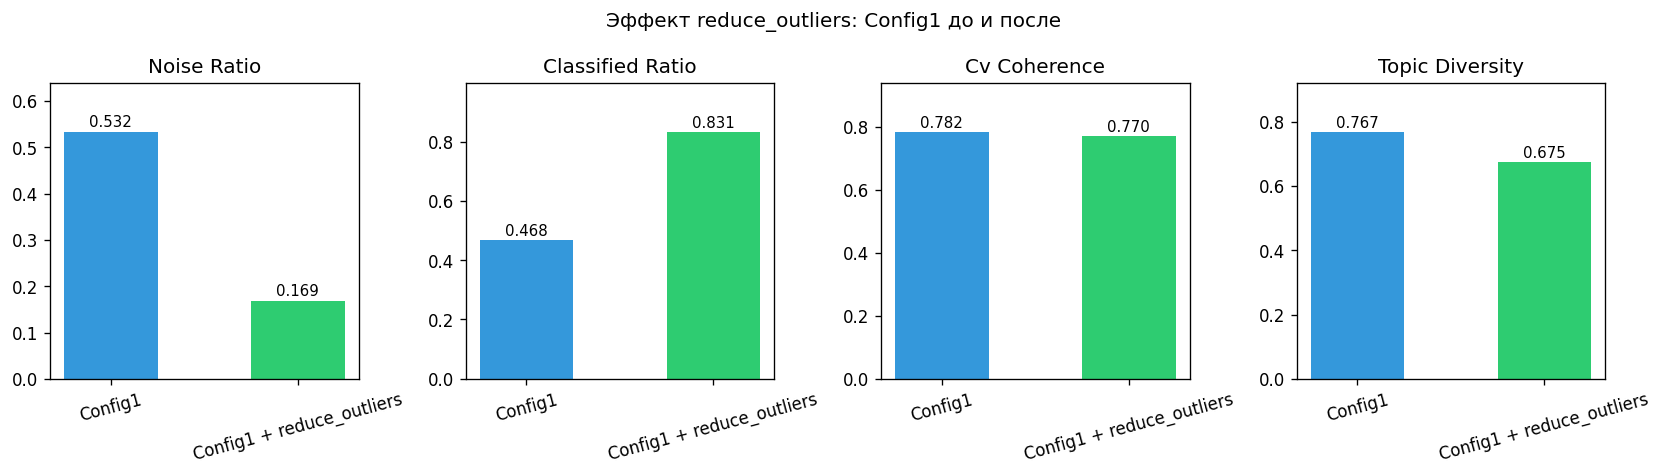

In [21]:
# Bar chart основных метрик
plot_metrics = ["noise_ratio", "classified_ratio", "cv_coherence", "topic_diversity"]
labels_plot = [
    metrics_before.get("label", "Config1 (до)"),
    metrics_after.get("label", "Config1 + reduce_outliers"),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
colors = ["#3498db", "#2ecc71"]

for ax, metric in zip(axes, plot_metrics):
    vals = [metrics_before[metric], metrics_after[metric]]
    bars = ax.bar(labels_plot, vals, color=colors, width=0.5)
    ax.set_title(metric.replace("_", " ").title())
    ax.set_ylim(0, max(vals) * 1.2)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Эффект reduce_outliers: Config1 до и после", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "metrics_before_after.png", bbox_inches="tight")
plt.show()

## 8. Анализ переназначенных документов

Sanity check: смотрим куда ушли бывшие outliers - равномерно по темам или в одну-две.

In [22]:
# Маска документов, которые были -1 и стали не -1
orig_arr   = np.array(topics_orig)
after_arr  = np.array(topics_after_emb)

reassigned_mask = (orig_arr == -1) & (after_arr != -1)
reassigned_topics = after_arr[reassigned_mask]

topic_counts = pd.Series(reassigned_topics).value_counts()
print(f'Всего переназначено: {reassigned_mask.sum():,}')
print(f'Распределено по {len(topic_counts)} темам')
print('\nТоп-10 тем по числу принятых outliers:')
print(topic_counts.head(10).to_string())

# Проверка: нет ли одной доминирующей темы (признак слишком жадной стратегии)
top1_share = topic_counts.iloc[0] / reassigned_mask.sum()
print(f'\nДоля топ-1 темы: {top1_share:.2%}')
if top1_share > 0.3:
    print('[!]\tБолее 30% outliers ушли в одну тему - стратегия может быть слишком жадной')
else:
    print('[+]\tРаспределение равномерное')

Всего переназначено: 36,342
Распределено по 231 темам

Топ-10 тем по числу принятых outliers:
4      876
58     687
5      620
14     552
12     551
15     520
173    511
11     504
7      493
198    436

Доля топ-1 темы: 2.41%
[+]	Распределение равномерное


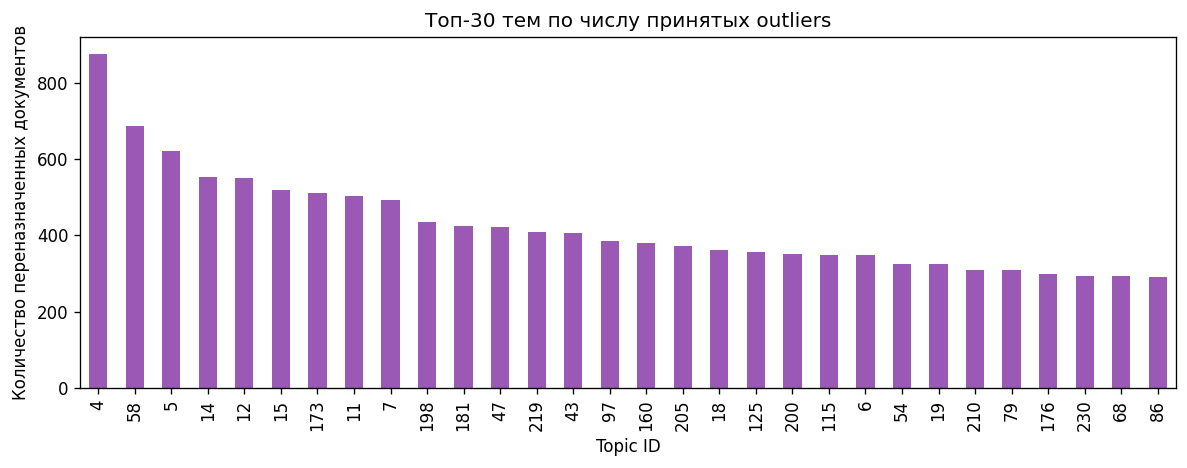

In [23]:
# Распределение переназначенных outliers по темам
fig, ax = plt.subplots(figsize=(10, 4))
topic_counts.head(30).plot(kind='bar', ax=ax, color='#9b59b6')
ax.set_title('Топ-30 тем по числу принятых outliers')
ax.set_xlabel('Topic ID')
ax.set_ylabel('Количество переназначенных документов')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'reassigned_distribution.png', bbox_inches='tight')
plt.show()

## 9. Примеры переназначенных документов

Ручная проверка качества переназначения на 10 случайных примерах.

In [24]:
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(np.where(reassigned_mask)[0], size=min(10, reassigned_mask.sum()), replace=False)

print('=== 10 случайных переназначенных документов ===')
for i, idx in enumerate(sample_idx):
    new_topic = after_arr[idx]
    top_words = [w for w, _ in topic_model.get_topic(new_topic)[:5]]
    doc_preview = docs_clean[idx][:150].replace('\n', ' ')
    print(f'\n[{i+1}] Topic {new_topic} ({", ".join(top_words)})')
    print(f'    {doc_preview}...')

=== 10 случайных переназначенных документов ===

[1] Topic 166 (налог, налоговый, ндфл, доход, ставка)
    Минэкономразвития разработало поправки в Трудовой кодекс, направленные на повышение гибкости рынка труда в условиях дефицита кадров, узнал РБК. Среди ...

[2] Topic 63 (взрыв, прогреметь, тревога, воздушный, издание)
    Взрывы прозвучали в Днепровском районе Херсона, который находится под контролем украинских властей. Об этом сообщил глава назначенной Киевом городской...

[3] Topic 229 (бастрыкин, дом, аварийный, жилец, проверка)
    Глава СК взял на контроль ситуацию с вырубкой Березовой рощи в Екатеринбурге В Информационном центре ведомства отметили ( что территория, на которой п...

[4] Topic 36 (должность, пост, заместитель, отставка, глава)
    Ректор УрФУ Виктор Кокшаров покидает свой пост, рассказали @66.RU ( два источника в вузе Отмечается, что Кокшаров останется во главе УрФУ как минимум ...

[5] Topic 219 (беглов, петербург, александр, петербургский, губернатор)
    ​​ 

## 10. Сохранение результатов

In [25]:
# Сохраняем переназначенные топики для использования в nb06
np.save(DATA_DIR / 'topics_config1_reduced.npy', np.array(topics_after_emb))

# Сохраняем финальную модель с обновлёнными репрезентациями
model_out = RESULTS_DIR / 'bertopic_config1_reduced'
topic_model.save(str(model_out))

# Сохраняем итоговые метрики
summary = {
    'thresholds': {
        'c_tf_idf': THRESHOLD_CTFIDF,
        'embeddings': THRESHOLD_EMB,
    },
    'reassigned_step1_ctfidf': int(reassigned_step1),
    'reassigned_step2_embeddings': int(reassigned_step2),
    'reassigned_total': int(reassigned_step1 + reassigned_step2),
    'metrics_before': metrics_before,
    'metrics_after': metrics_after,
}
with open(RESULTS_DIR / 'noise_filtering_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('Сохранено:')
print('\tdata/topics_config1_reduced.npy')
print('\tresults/noise_filtering/bertopic_config1_reduced/')
print('\tresults/noise_filtering/noise_filtering_summary.json')
print('\tresults/noise_filtering/metrics_comparison.csv')

2026-05-02 14:57:28,843 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Сохранено:
	data/topics_config1_reduced.npy
	results/noise_filtering/bertopic_config1_reduced/
	results/noise_filtering/noise_filtering_summary.json
	results/noise_filtering/metrics_comparison.csv


## 11. Итог

**Ключевые числа для таблицы в ВКР (раздел 2.3.X):**

| Конфигурация | Тем | Noise↓ | Classified↑ | DBCV↑* | C_V↑ | Diversity |
|---|---|---|---|---|---|---|
| Config1 (до) | - | - | - | - | - | - |
| Config1 + reduce_outliers | - | - | - | n/a* | - | - |

*DBCV после `update_topics` не пересчитывается корректно, поскольку UMAP-проекция остаётся от исходной кластеризации - это ожидаемое ограничение метрики, а не деградация модели.

**Методологическая заметка:**  
Разделение на два этапа (оптимизация гиперпараметров в nb05 -> постобработка шума в nb05_1)  
соответствует рекомендованной схеме Grootendorst: гиперпараметры оптимизируются  
по качеству кластеризации (DBCV), а `reduce_outliers` применяется как отдельный downstream-шаг,  
не влияющий на структуру HDBSCAN-дерева.